In [1]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import joblib

In [12]:
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("dataset/dataset.csv")
df.head()


,name,student_id,age,gender,attendance,scholarship,co_curricular_activities,marks,assignment_submission,debtor,displaced,income,prediction
0,Aarav,S001,11,Male,95,Yes,Yes,88,Yes,No,No,180000,Low
1,Ananya,S002,12,Female,92,Yes,Yes,91,Yes,No,No,160000,Low
2,Rahul,S003,13,Male,68,No,No,45,Half,Yes,Yes,70000,High
3,Priya,S004,10,Female,85,Yes,Yes,78,Yes,No,No,140000,Low
4,Mohit,S005,14,Male,74,No,No,55,Half,Yes,No,90000,Medium


In [4]:
df.shape

(1186, 13)

In [5]:
df = df.drop(['name','student_id'],axis='columns')

In [6]:
df

,age,gender,attendance,scholarship,co_curricular_activities,marks,assignment_submission,debtor,displaced,income,prediction
0,11,Male,95,Yes,Yes,88,Yes,No,No,180000,Low
1,12,Female,92,Yes,Yes,91,Yes,No,No,160000,Low
2,13,Male,68,No,No,45,Half,Yes,Yes,70000,High
3,10,Female,85,Yes,Yes,78,Yes,No,No,140000,Low
4,14,Male,74,No,No,55,Half,Yes,No,90000,Medium
...,...,...,...,...,...,...,...,...,...,...,...
1181,14,Female,90,Yes,No,91,Yes,No,No,184219,Low
1182,15,Male,78,No,Yes,65,Half,Yes,No,108423,Medium
1183,10,Male,81,Yes,No,96,Yes,No,No,149957,Low
1184,11,Male,73,No,No,62,Half,Yes,No,118984,Medium


# EDA

In [7]:
marks_avg=df["marks"].mean()
marks_avg

np.float64(64.33642495784149)

In [8]:
income_avg=df["income"].mean()
income_avg

np.float64(127311.90472175379)

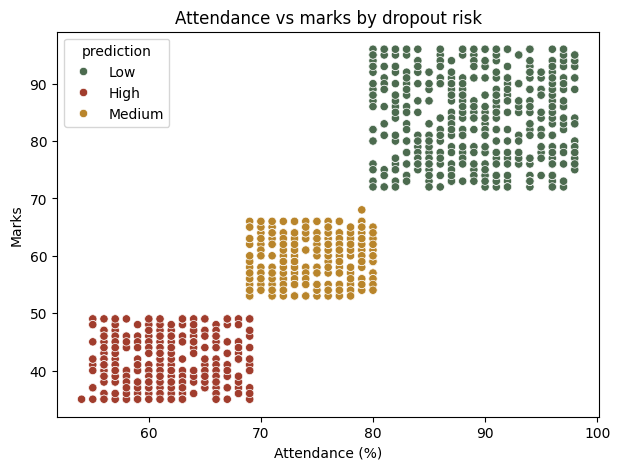

In [9]:

# fix the dirty label before plotting
df.loc[df["prediction"] == "LowA", "prediction"] = "Low"


# scatter: attendance vs marks, colored by dropout risk
plt.figure(figsize=(7,5))
sn.scatterplot(
    data=df, x="attendance", y="marks", hue="prediction",
    palette={"Low": "#4C6B4F", "Medium": "#B9852B", "High": "#A13D2D"}
)
plt.title("Attendance vs marks by dropout risk")
plt.xlabel("Attendance (%)")
plt.ylabel("Marks")
plt.show()

In [10]:
x=df.drop(["prediction"],axis="columns")
y=df.prediction

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
le=LabelEncoder()

In [ ]:
df["prediction"]=le.fit_transform(df[["prediction"]])